# Integrative Analysis of Breast Cancer Susceptibility Loci and Tumor Immune Programs Reveals Immune-Associated Candidate Genes in Triple-Negative Breast Cancer

---
## Notebook 1 - GWAS Data Acquisition and Quality Assessment


### Objective

This notebook downloads publicly available genome-wide association study (GWAS) summary statistics for triple-negative breast cancer (TNBC), standardizes the dataset into a consistent format, performs quality control assessment, and identifies genome-wide significant susceptibility loci for downstream analyses.

### Biological Background

Genome-wide association studies (GWAS) identify inherited genetic variants associated with disease susceptibility by testing millions of single nucleotide polymorphisms (SNPs) across the human genome.

Unlike transcriptomic studies, which measure gene activity within tumors, GWAS captures germline genetic variation that exists before tumor development. These inherited variants often influence disease risk through subtle regulatory effects rather than direct coding mutations.

Before interpreting GWAS findings biologically, it is important to assess data quality and verify that the observed association statistics are not driven by systematic bias.

In [1]:
import requests
from io import StringIO
import urllib3

import pandas as pd
import numpy as np

import scipy.stats as stats

import matplotlib.pyplot as plt
import seaborn as sns

### 1. Download TNBC GWAS summary statistics from the GWAS Catalog.

In [2]:
url = "https://ftp.ebi.ac.uk/pub/databases/gwas/summary_statistics/GCST010001-GCST011000/GCST010100/harmonised/GCST010100.h.tsv.gz"
print("Downloading TNBC-specific GWAS summary statistics from EBI...")

df_gwas = pd.read_csv(url, sep='\t', compression='gzip', low_memory=False)

print(f"TNBC Dataset loaded successfully!")
print(f"Total SNPs loaded: {df_gwas.shape[0]}")

print("Raw columns:")
print(df_gwas.columns.tolist())

TNBC Dataset loaded successfully!
Total SNPs loaded: 15380108
Raw columns:
['chromosome', 'base_pair_location', 'effect_allele', 'other_allele', 'beta', 'standard_error', 'effect_allele_frequency', 'p_value', 'variant_id', 'rsid', 'hm_coordinate_conversion', 'hm_code']


### 2. Standardize and clean the summary statistics.

In [3]:
rename_dict = {
    'rsid': 'rsid',
    'chromosome': 'chromosome',
    'base_pair_location': 'position',
    'p_value': 'p_value',
    'beta': 'beta',
    'effect_allele': 'effect_allele'
}

df_standard = df_gwas[list(rename_dict.keys())].rename(columns=rename_dict)

df_standard = df_standard.dropna(subset=['rsid', 'chromosome', 'position', 'p_value'])

df_standard['chromosome'] = df_standard['chromosome'].astype(str)

print(f"Standardized dataset contains {df_standard.shape[0]} SNPs.")
print("Clean columns:", df_standard.columns.tolist())

Standardized dataset contains 15380108 SNPs.
Clean columns: ['rsid', 'chromosome', 'position', 'p_value', 'beta', 'effect_allele']


In [4]:
df_standard.to_csv("../data/gwas/gwas_summary_stats_raw.tsv.gz", sep='\t', index=False, compression='gzip')
print("Data saved cleanly as a compressed TSV file!")

Data saved cleanly as a compressed TSV file!


### 3. Perform quality control.

In [5]:
df = pd.read_csv("../data/gwas/gwas_summary_stats_raw.tsv.gz", sep='\t')
print(f"Loaded {df.shape[0]} SNPs for Quality Control.")

Loaded 15380108 SNPs for Quality Control.


In [6]:
df = df[df['p_value'] > 0]

df['minus_log10_p'] = -np.log10(df['p_value'])
df['minus_log10_p'].describe()

count    1.538011e+07
mean     4.564270e-01
std      4.942843e-01
min     -0.000000e+00
25%      1.294205e-01
50%      3.131850e-01
75%      6.289321e-01
max      6.301511e+01
Name: minus_log10_p, dtype: float64

### 4. Generate a genomic inflation (Q-Q) plot.

[SUCCESS] Figure 1 exported. Lambda GC: 1.066


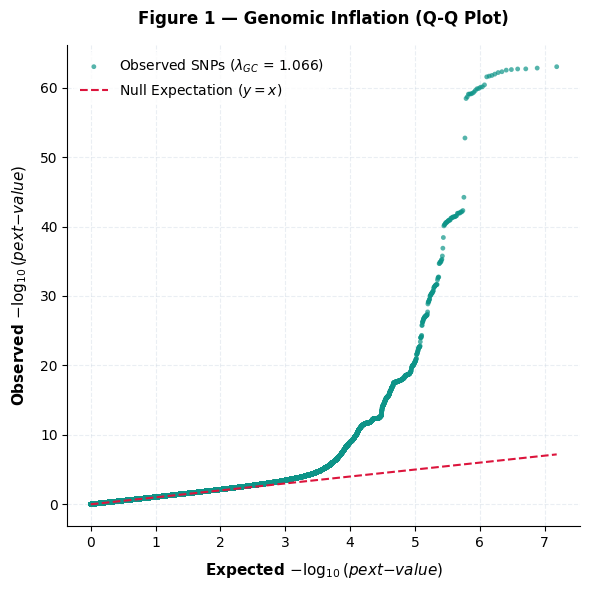

In [7]:
n_snps = len(df)
observed_p = np.sort(df['p_value'])
observed_log = -np.log10(observed_p)

expected_p = np.arange(1, n_snps + 1) / (n_snps + 1)
expected_log = -np.log10(expected_p)

chisq_observed = stats.chi2.ppf(1 - df['p_value'], df=1)
lambda_gc = np.median(chisq_observed) / stats.chi2.ppf(0.5, df=1)

fig, ax = plt.subplots(figsize=(6, 6))

ax.scatter(
    expected_log, 
    observed_log, 
    c='#0D9488',       
    edgecolors='none', 
    s=12, 
    alpha=0.7,
    label=f'Observed SNPs ($\lambda_{{GC}}$ = {lambda_gc:.3f})'
)

max_val = max(expected_log)
ax.plot([0, max_val], [0, max_val], color='crimson', linestyle='--', linewidth=1.5, label='Null Expectation ($y = x$)')

ax.set_xlabel('Expected $-\log_{10}(p\text{-value})$', fontsize=11, fontweight='bold', labelpad=8)
ax.set_ylabel('Observed $-\log_{10}(p\text{-value})$', fontsize=11, fontweight='bold', labelpad=8)
ax.set_title('Figure 1 — Genomic Inflation (Q-Q Plot)', fontsize=12, fontweight='bold', pad=15)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(loc='upper left', frameon=True, facecolor='white', edgecolor='none')
ax.grid(True, linestyle='--', alpha=0.4, color='#CBD5E1')
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('../results/figures/qq_plot.png', dpi=300, bbox_inches='tight')
print(f"Lambda GC: {lambda_gc:.3f}")

#### Interpretation

The Q-Q plot demonstrates minimal genomic inflation (λGC ≈ 1.07), indicating that the observed association statistics closely follow the expected null distribution across most variants.

Only the extreme tail deviates markedly from expectation, suggesting that the strongest associations are unlikely to result from systematic bias and instead represent genuine disease-associated loci suitable for downstream analysis.

### 5. Generate a Manhattan plot.

In [8]:
df = df[df['chromosome'].isin([i for i in range(1, 23)])]
df = df.sort_values(['chromosome', 'position'])

In [9]:
df_significant = df[df['p_value'] < 0.01]
df_noise = df[df['p_value'] >= 0.01].sample(frac=0.05, random_state=42) 

df_plot = pd.concat([df_significant, df_noise]).sort_values(['chromosome', 'position'])
print(f"Reduced plotting data from {len(df)} to {len(df_plot)} rows for performance optimization.")

Reduced plotting data from 15380108 to 960399 rows for performance optimization.


In [10]:
df_plot['i'] = range(len(df_plot))
df_plot['minus_log10_p'] = -np.log10(df_plot['p_value'])

grouped_df = df_plot.groupby('chromosome')
chron_max_pos = {}
cumulative_pos = 0

df_plot['tot_pos'] = 0
for name, group in grouped_df:
    df_plot.loc[df_plot['chromosome'] == name, 'tot_pos'] = group['position'] + cumulative_pos
    chron_max_pos[name] = cumulative_pos + group['position'].max()
    cumulative_pos += group['position'].max()

axis_df = df_plot.groupby('chromosome')['tot_pos'].median().reset_index()

[SUCCESS] Figure 2 successfully exported to results archive.


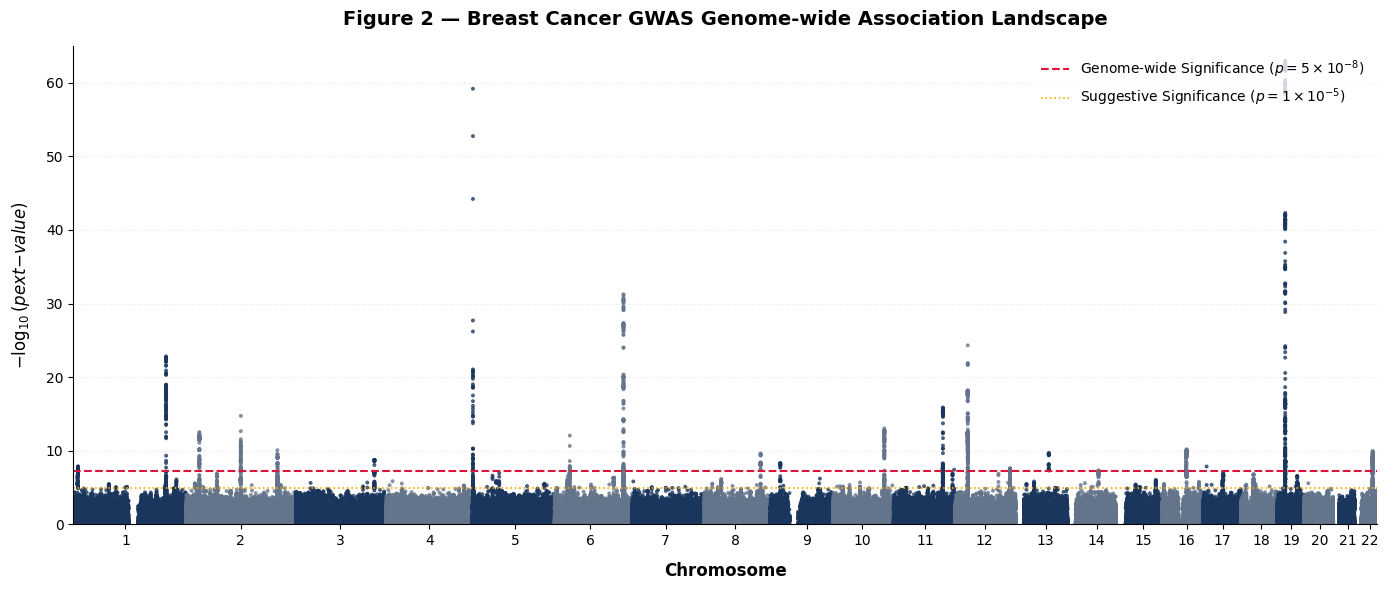

In [11]:
fig, ax = plt.subplots(figsize=(14, 6))

colors = ['#1A365D', '#64748B']  

for num, (name, group) in enumerate(df_plot.groupby('chromosome')):
    ax.scatter(
        group['tot_pos'], 
        group['minus_log10_p'], 
        c=colors[num % 2], 
        edgecolors='none', 
        s=8, 
        alpha=0.8
    )

sig_line = -np.log10(5e-8)
ax.axhline(y=sig_line, color='crimson', linestyle='--', linewidth=1.5, label='Genome-wide Significance ($p = 5 \\times 10^{{-8}}$)')

ax.axhline(y=-np.log10(1e-5), color='orange', linestyle=':', linewidth=1.2, label='Suggestive Significance ($p = 1 \\times 10^{{-5}}$)')

ax.set_xticks(axis_df['tot_pos'])
ax.set_xticklabels(axis_df['chromosome'], fontsize=10)

ax.set_xlabel('Chromosome', fontsize=12, fontweight='bold', labelpad=10)
ax.set_ylabel('$-\log_{10}(p\text{-value})$', fontsize=12, fontweight='bold', labelpad=10)
ax.set_title('Figure 2 — Breast Cancer GWAS Genome-wide Association Landscape', fontsize=14, fontweight='bold', pad=15)

ax.set_xlim([0, df_plot['tot_pos'].max()])
ax.set_ylim([0, df_plot['minus_log10_p'].max() + 2])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.legend(loc='upper right', frameon=True, facecolor='white', edgecolor='none')
ax.grid(axis='y', linestyle='--', alpha=0.3, color='#CBD5E1')
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('../results/figures/manhattan_plot.png', dpi=300, bbox_inches='tight')
print("[SUCCESS] Figure 2 successfully exported to results archive.")

#### Interpretation

Genome-wide association testing identified multiple chromosomal regions exceeding the accepted genome-wide significance threshold (P < 5 × 10⁻⁸).

These peaks represent candidate susceptibility loci that may contribute to inherited TNBC risk and form the basis for subsequent SNP-to-gene mapping and functional characterization.

### 6. Identify genome-wide significant SNPs (P < 5 × 10⁻⁸).

In [12]:
significant_snps = df_plot[df_plot['p_value'] < 5e-8].copy()

print(f"Discovered {len(significant_snps)} SNPs with genome-wide significance.")

Discovered 2085 SNPs with genome-wide significance.


### 7. Export significant loci for downstream SNP-to-gene mapping.

In [13]:
significant_snps.to_csv("../data/gwas/gwas_significant_hits.tsv", sep='\t', index=False)

### Notebook Summary

This notebook established a high-quality GWAS dataset by confirming appropriate statistical calibration and identifying genome-wide significant susceptibility loci.

These loci provide the foundation for subsequent biological interpretation and gene mapping analyses performed in later notebooks.